## Beam image fitting code

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from PIL import Image
from tabulate import tabulate

px_to_um_flir = 3.45  # pixel-to-micron conversion factor
px_to_um_thorlabs = 5.2 

### Gaussian beam fitting

In [2]:
mask_threshold = 250  # Threshold for identifying saturating pixels


def gaussian_1d(x, amplitude, mean, stddev, offset):
    return amplitude * np.exp(-((x - mean)**2) / (2 * stddev**2)) + offset

def gaussian_2d(xy, amplitude, x0, y0, sigma_x, sigma_y, theta, offset):
    x, y = xy
    a = (np.cos(theta)**2) / (2 * sigma_x**2) + (np.sin(theta)**2) / (2 * sigma_y**2)
    b = -(np.sin(2 * theta)) / (4 * sigma_x**2) + (np.sin(2 * theta)) / (4 * sigma_y**2)
    c = (np.sin(theta)**2) / (2 * sigma_x**2) + (np.cos(theta)**2) / (2 * sigma_y**2)
    g = amplitude * np.exp(-(a * (x - x0)**2 + 2 * b * (x - x0) * (y - y0) + c * (y - y0)**2)) + offset
    return g.ravel()

def normalized_root_mean_square_error(data, fit):
    residuals = data - fit
    rmse = np.sqrt(np.mean(residuals**2))
    norm_rmse = rmse / (np.max(data) - np.min(data))
    if np.max(data) == mask_threshold:
        print("Image has saturating pixels. Normalized RMSE may be inaccurate.")
    return norm_rmse

def fit_image_data(image_path, title='', px_to_um = 3.45, figsize=(4,3), mask_saturating=False):
    # 1. Load Image
    img = Image.open(image_path).convert('L')  # Convert to grayscale
    data = np.asarray(img, dtype=float)
    
    rows, cols = data.shape
    ratio = data.shape[0] / data.shape[1]
    x = np.arange(cols)
    y = np.arange(rows)
    X, Y = np.meshgrid(x, y)

    # 2. Marginal Projections (1D)
    x_data = np.sum(data, axis=0)
    y_data = np.sum(data, axis=1)

    # Initial guesses for 1D [amp, mean, stddev, offset]
    p0_x = [np.max(x_data), np.argmax(x_data), 10, np.min(x_data)]
    p0_y = [np.max(y_data), np.argmax(y_data), 10, np.min(y_data)]

    # Create a sigma array (default uncertainty of 1.0)
    Z_flat = data.ravel()
    sigmas = np.ones_like(Z_flat)

    # Mask saturating pixels if requested
    if mask_saturating:
        # # Assign high uncertainty to saturated pixels
        sigmas[Z_flat >= mask_threshold] = 1e10
        print(f"Masked {np.sum(Z_flat >= mask_threshold)} saturating pixels.")
        
    popt_x, pcov_x = curve_fit(gaussian_1d, x, x_data, p0=p0_x)
    popt_y, pcov_y = curve_fit(gaussian_1d, y, y_data, p0=p0_y)

    perr_x = np.sqrt(np.diag(pcov_x))
    perr_y = np.sqrt(np.diag(pcov_y))

    # 3. Full 2D Fit
    # Initial guess: [amp, x0, y0, sigma_x, sigma_y, theta, offset]
    p0_2d = [np.max(data), popt_x[1], popt_y[1], popt_x[2], popt_y[2], 0, np.min(data)]
    
    # Flatten grid for curve_fit
    popt_2d, pcov_2d = curve_fit(gaussian_2d, (X, Y), Z_flat, p0=p0_2d, sigma=sigmas)
    perr_2d = np.sqrt(np.diag(pcov_2d))

    # 4. Printing Results
    print("--- 1D Marginal Fits ---")
    print(f"X-Margin Width (sigma): {px_to_um*abs(popt_x[2]):.0f}({1e1*px_to_um*abs(perr_x[2]):.0f})" + r"um")
    print(f"Y-Margin Width (sigma): {px_to_um*abs(popt_y[2]):.0f}({1e1*px_to_um*abs(perr_y[2]):.0f})" + r"um")
    
    print("\n--- 2D Gaussian Fit ---")
    if perr_2d[3] > 1e3 or perr_2d[4] > 1e3:
        print("Warning: Large uncertainties in width parameters. Fit may be unreliable.")
    print(f"Sigma_X: {px_to_um*abs(popt_2d[3]):.1f}({1e1*px_to_um*abs(perr_2d[3]):.0f})" + r"um")
    print(f"Sigma_Y: {px_to_um*abs(popt_2d[4]):.1f}({1e1*px_to_um*abs(perr_2d[4]):.0f})" + r"um")
    print(f"Rotation (Skew) Theta: {popt_2d[5]:.3f}({1e1*perr_2d[5]:.3f}) rad")
    print(f" or {np.degrees(popt_2d[5]):.1f}({10*np.degrees(perr_2d[5]):.1f})°")

    # 5. Plotting
    fig, axes = plt.subplots(2, 2, figsize=(figsize[0]*2, figsize[1]*1.5))
    axs = axes.flatten()

    for ax in axs[:2]:
        ax.set_xlabel('x (px)')
        ax.set_ylabel('y (px)')

    ### Image with 2D fit contour
    ax = axs[0]
    im = ax.imshow(data, cmap='viridis', origin='upper')
    # ax.set_title(title)
    
    # Overlay 2D fit contour
    Z_fit = gaussian_2d((X, Y), *popt_2d).reshape(rows, cols)
    ax.contour(X, Y, Z_fit, colors='w', alpha=0.5)
    plt.colorbar(im, shrink=ratio*1.25)

    ### Residuals
    ax = axs[1]
    residuals = data - Z_fit
    im = ax.imshow(residuals, cmap='bwr', origin='upper')
    # ax.set_title('Residuals (Data - Fit)')
    plt.colorbar(im, shrink=ratio*1.25)

    NRMSE = normalized_root_mean_square_error(data, Z_fit)

    ### Plot margins
    ax = axs[2]
    ax.set(xlabel='x (px)')
    ax.set_box_aspect(0.25) 
    ax.plot(x, x_data, 'b-', label='Data')
    ax.plot(x, gaussian_1d(x, *popt_x), 'r--', label='Fit')
    ax.legend()

    ax = axs[3]
    ax.set_box_aspect(0.25)
    ax.set(xlabel='y (px)')
    ax.plot(y, y_data, 'b-', label='Data')
    ax.plot(y, gaussian_1d(y, *popt_y), 'r--', label='Fit')
    ax.legend()

    ### Fit parameter table
    param_names = ["(X0, Y0)", "1/e width (σX,σY) [um]", "width error [um]", "NRMSE"]
    param_values = [f"({popt_2d[1]:.3f}, {popt_2d[2]:.3f})"]
    param_values += [f"({px_to_um*abs(popt_2d[3]):.1f}, {px_to_um*abs(popt_2d[4]):.1f})"]
    param_values += [f"({px_to_um*abs(perr_2d[3]):.1f}, {px_to_um*abs(perr_2d[4]):.1f})"]
    param_values += [f"{NRMSE:.3f}"]
    table_data = list(zip(param_names, param_values))
    table = tabulate(table_data, headers=["Parameter", "Value"], tablefmt="grid")
    print("\n--- 2D Fit Parameters ---")
    print(table)

    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

    if perr_2d[3] > 1e3 or perr_2d[4] > 1e3:
        print("\nNote: Large uncertainties in 2D fit widths suggest the fit may be unreliable. Returning 1D marginal widths for a more robust estimate.")

        popt_2d[3] = popt_x[2]  # Replace sigma_x with 1D fit value
        perr_2d[3] = perr_x[2]  # Replace sigma_x error with 1D fit error
        popt_2d[4] = popt_y[2]  # Replace sigma_y with 1D fit value
        perr_2d[4] = perr_y[2]  # Replace sigma_y error with 1D fit error

    return popt_2d, perr_2d, NRMSE

## Fit D1 beam images

Masked 1 saturating pixels.
--- 1D Marginal Fits ---
X-Margin Width (sigma): 443(23)um
Y-Margin Width (sigma): 460(68)um

--- 2D Gaussian Fit ---
Sigma_X: 442.8(2)um
Sigma_Y: 483.7(2)um
Rotation (Skew) Theta: 0.315(0.040) rad
 or 18.0(2.3)°

--- 2D Fit Parameters ---
+------------------------+--------------------+
| Parameter              | Value              |
+========================+====================+
| (X0, Y0)               | (612.017, 520.616) |
+------------------------+--------------------+
| 1/e width (σX,σY) [um] | (442.8, 483.7)     |
+------------------------+--------------------+
| width error [um]       | (0.2, 0.2)         |
+------------------------+--------------------+
| NRMSE                  | 0.027              |
+------------------------+--------------------+


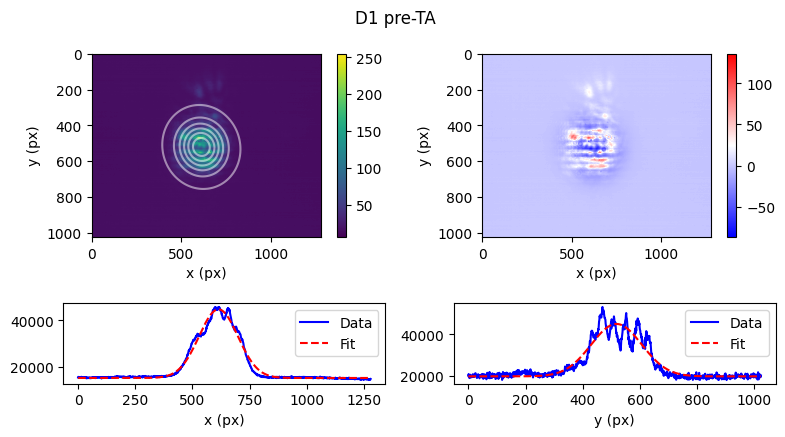

Masked 0 saturating pixels.
--- 1D Marginal Fits ---
X-Margin Width (sigma): 456(7)um
Y-Margin Width (sigma): 943(104)um

--- 2D Gaussian Fit ---
Sigma_X: 455.7(2)um
Sigma_Y: 948.4(3)um
Rotation (Skew) Theta: 0.011(0.003) rad
 or 0.6(0.2)°

--- 2D Fit Parameters ---
+------------------------+--------------------+
| Parameter              | Value              |
+========================+====================+
| (X0, Y0)               | (574.846, 537.941) |
+------------------------+--------------------+
| 1/e width (σX,σY) [um] | (455.7, 948.4)     |
+------------------------+--------------------+
| width error [um]       | (0.2, 0.3)         |
+------------------------+--------------------+
| NRMSE                  | 0.031              |
+------------------------+--------------------+


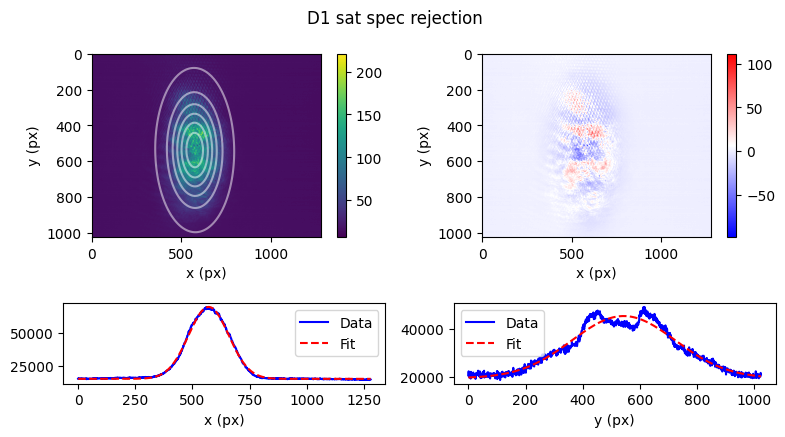

In [4]:
image_folder = '../data/D1_images/'

camera_px_to_um = px_to_um_thorlabs
suffix = ".tif"

images = [
        'D1_pre_TA',
        'D1_sat_spec_rejection',
        ]

image_names = [
        'D1 pre-TA',
        'D1 sat spec rejection',
        ]


for i, image in enumerate(images):
    image_file = image_folder + image + suffix
    title = image_names[i]
    popt, perr, _ = fit_image_data(image_file, title=title, figsize=(4,3), 
                                    px_to_um=camera_px_to_um, mask_saturating=True)
